<a href="https://colab.research.google.com/github/raja016956/My_Projects/blob/main/AI_Powered_QSAR_Modelling_of_Bioactive_Compounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI-Driven QSAR Modeling**


**Objective:** Predict pIC50 values of EGFR inhibitors using ChEMBL bioactivity data, molecular fingerprints, descriptors, and machine learning.

# **1. Setup Environment**

In [ ]:
! pip install chembl_webresource_client
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 29.5 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import AllChem

# **2. Fetch Bioactivity Data**

###**2.1 Target Search: EGFR (Epidermal Growth Factor Receptor)**

In [ ]:
# Target search
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)
targets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cross_references    20 non-null     object 
 1   organism            20 non-null     object 
 2   pref_name           20 non-null     object 
 3   score               20 non-null     float64
 4   species_group_flag  20 non-null     bool   
 5   target_chembl_id    20 non-null     object 
 6   target_components   20 non-null     object 
 7   target_type         20 non-null     object 
 8   tax_id              20 non-null     int64  
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 1.4+ KB


### **2.2 Filter Human Single-Protein Target**

In [ ]:
# Extract the desired data
# Filter the dataframe
targets_clean = targets[
    (targets['organism'] == 'Homo sapiens') &
    (targets['target_type'] == 'SINGLE PROTEIN')
]

targets_clean[['pref_name', 'target_chembl_id', 'score']]


,pref_name,target_chembl_id,score
3,Epidermal growth factor receptor,CHEMBL203,12.0
9,Receptor tyrosine-protein kinase erbB-2,CHEMBL1824,9.0
11,Receptor tyrosine-protein kinase erbB-4,CHEMBL3009,9.0
12,Receptor tyrosine-protein kinase erbB-3,CHEMBL5838,9.0


Choosing CHEMBL203 because it is the canonical human EGFR single-protein target

### **2.3 Fetch Compounds Tested Against EGFR**

In [ ]:
activity = new_client.activity.filter(
    target_chembl_id='CHEMBL203',
    standard_type='IC50',
    standard_units='nM',
    assay_type='B'   # Binding assays = cleaner
)[:5000]

df_act = pd.DataFrame.from_dict(activity)


In [ ]:
df_act.target_chembl_id.unique()

array(['CHEMBL203'], dtype=object)

In [ ]:
df_act.standard_type.unique()

array(['IC50'], dtype=object)

In [ ]:
df_act.to_csv('/content/drive/MyDrive/Colab Notebooks/EGFR_bioactivity_data.csv', index=False)

### **2.4 Load Data for Processing**

In [ ]:
df= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/EGFR_bioactivity_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                0 non-null      float64
 1   activity_comment           94 non-null     object 
 2   activity_id                5000 non-null   int64  
 3   activity_properties        5000 non-null   object 
 4   assay_chembl_id            5000 non-null   object 
 5   assay_description          5000 non-null   object 
 6   assay_type                 5000 non-null   object 
 7   assay_variant_accession    100 non-null    object 
 8   assay_variant_mutation     100 non-null    object 
 9   bao_endpoint               5000 non-null   object 
 10  bao_format                 5000 non-null   object 
 11  bao_label                  5000 non-null   object 
 12  canonical_smiles           4992 non-null   object 
 13  data_validity_comment      176 non-null    objec

# **3. Clean Activity Data**

### **3.1 Filter Exact Measurements**

In [ ]:
df_clean = df[
    (df['standard_relation'] == '=') &  # exact measured(=) value no < or >
    (df['standard_units'] == 'nM') &    # units= nM
    (df['canonical_smiles'].notna())    # remove missing chemical structures
].copy()

df_clean.head(3)

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.041
1,NaN,NaN,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.170
2,NaN,NaN,32680,[],CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,9.300


### **3.2 Assign Bioactivity Classes**
---
| IC50 (nM) | Class      |
|-----------|------------|
|≤ 1000	    |Active      |
|1000-10000	|Intermediate|
|≥ 10000	  |Inactive    |


In [ ]:
# Create a function to assign bioactivity class
def classify_bioactivity(ic50):
    if ic50 <= 1000:
        return 'active'
    elif ic50 >= 10000:
        return 'inactive'
    else:
        return 'intermediate'


In [ ]:
# Apply classification to dataset
df_clean['bioactivity_class'] = df_clean['standard_value'].apply(classify_bioactivity)


In [ ]:
df_clean['bioactivity_class'].value_counts()

,count
bioactivity_class,
active,2509
intermediate,877
inactive,649


**Removing the 'intermediate' bioactivity class**

In [ ]:
df_classification = df_clean[df_clean['bioactivity_class'] != 'intermediate']
df_classification['bioactivity_class'].value_counts()

,count
bioactivity_class,
active,2509
inactive,649


### **3.3 Convert to PIC50**

In [ ]:
df_clean['pIC50'] = -np.log10(df_clean['standard_value'] * 1e-9)
df_clean[['standard_value', 'pIC50']].head()



,standard_value,pIC50
0,41.0,7.387216
1,170.0,6.769551
2,9300.0,5.031517
3,500000.0,3.301030
4,3000000.0,2.522879


### **3.4 Remove Duplicate Molecules**

In [ ]:
df_final = df_clean.groupby(
    ['molecule_chembl_id', 'canonical_smiles'],
    as_index=False
)['pIC50'].mean()

df_final.shape


(3097, 3)

In [ ]:
df_final.head()

,molecule_chembl_id,canonical_smiles,pIC50
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,4.017729
1,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,4.293183
2,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,6.339419
3,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...,5.484537
4,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,5.136677


# **4. Molecular Representation**

### **4.1 Convert SMILES → Molecules**

In [ ]:
# Convert SMILES strings to RDKit molecule objects
df_final['mol'] = df_final['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

### **4.2 Generate Molecular Fingerprints**

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)

def mol_to_fp(mol):
    """Convert molecule to Morgan fingerprint."""
    return mfpgen.GetFingerprint(mol)

df_final['fingerprint'] = df_final['mol'].apply(mol_to_fp)

### **4.3 Lipinski Descriptors**

In [ ]:
from rdkit.Chem import Descriptors, Lipinski

def lipinski(smiles_list, verbose=False):
    """Compute Lipinski descriptors: MW, LogP, H-bond donors & acceptors."""
    rows = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            # Handle invalid SMILES strings by appending NaN values
            rows.append([np.nan, np.nan, np.nan, np.nan])
        else:
            # Calculate Lipinski descriptors
            mw = Descriptors.MolWt(mol)
            logp = Descriptors.MolLogP(mol)
            hdonors = Lipinski.NumHDonors(mol)
            hacceptors = Lipinski.NumHAcceptors(mol)
            rows.append([mw, logp, hdonors, hacceptors])

    cols = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']
    return pd.DataFrame(rows, columns=cols)

df_lipinski = lipinski(df_final['canonical_smiles'])

print("Lipinski descriptors calculated successfully.")
df_lipinski.head()

Lipinski descriptors calculated successfully.


,MW,LogP,NumHDonors,NumHAcceptors
0,377.444,4.6822,1,3
1,197.190,0.0522,4,4
2,346.821,5.0126,1,4
3,440.463,4.0286,2,7
4,337.810,4.5994,2,3


### **4.4 2D Molecular Descriptors**

In [ ]:

def calc_2D_descriptors(smiles_list):
    """Calculate selected 2D molecular descriptors."""
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            # Handle invalid SMILES strings by appending NaN values
            rows.append([np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])
        else:
            # Calculate 2D molecular descriptors
            tpsa = Descriptors.TPSA(mol)
            rot_bonds = Descriptors.NumRotatableBonds(mol)
            ring_count = mol.GetRingInfo().NumRings() # Corrected line
            frac_csp3 = Descriptors.FractionCSP3(mol)
            heavy_atoms = Descriptors.HeavyAtomCount(mol)
            mol_wt_2d = Descriptors.MolWt(mol) # Using MolWt from Descriptors
            rows.append([tpsa, rot_bonds, ring_count, frac_csp3, heavy_atoms, mol_wt_2d])

    cols = ["TPSA", "RotBonds", "RingCount", "FracCSP3", "HeavyAtoms", "MolWt2D"]
    return pd.DataFrame(rows, columns=cols)

df_2D = calc_2D_descriptors(df_final['canonical_smiles'])

print("2D molecular descriptors calculated successfully.")
df_2D.head()

2D molecular descriptors calculated successfully.


,TPSA,RotBonds,RingCount,FracCSP3,HeavyAtoms,MolWt2D
0,64.63,4,4,0.047619,27,377.444
1,103.78,3,1,0.222222,14,197.190
2,50.70,4,4,0.050000,25,346.821
3,118.81,7,5,0.125000,33,440.463
4,54.02,5,3,0.052632,24,337.810


### **4.5 Combine Fingerprints + Lipinski + 2D Descriptors**

In [ ]:

df_combined = pd.concat([df_final, df_lipinski, df_2D], axis=1)

# Remove rows with missing target values
df_combined.dropna(subset=['pIC50'], inplace=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3096 entries, 0 to 3096
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  3096 non-null   object 
 1   canonical_smiles    3096 non-null   object 
 2   pIC50               3096 non-null   float64
 3   mol                 3096 non-null   object 
 4   fingerprint         3096 non-null   object 
 5   MW                  3096 non-null   float64
 6   LogP                3096 non-null   float64
 7   NumHDonors          3096 non-null   int64  
 8   NumHAcceptors       3096 non-null   int64  
 9   TPSA                3096 non-null   float64
 10  RotBonds            3096 non-null   int64  
 11  RingCount           3096 non-null   int64  
 12  FracCSP3            3096 non-null   float64
 13  HeavyAtoms          3096 non-null   int64  
 14  MolWt2D             3096 non-null   float64
dtypes: float64(6), int64(5), object(4)
memory usage: 387.0+ KB


# **5. Prepare Feature Matrix**

### **5.1 Fingerprints as Numeric Matrix**

In [ ]:
# Fingerprints as numeric matrix
fp_matrix = np.array(df_combined['fingerprint'].apply(lambda x: list(x)).tolist())

print("Fingerprint matrix (fp_matrix) shape:", fp_matrix.shape)

Fingerprint matrix (fp_matrix) shape: (3096, 2048)


### **5.2 Combine Features + Remove Low-Variance**

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Lipinski descriptors
X_lipinski = df_combined[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].values

# 2D descriptors
X_2D = df_combined[['TPSA', 'RotBonds', 'RingCount', 'FracCSP3', 'HeavyAtoms', 'MolWt2D']].values

# Combine all numerical features
X = np.concatenate([fp_matrix, X_lipinski, X_2D], axis=1)

# Target variable
y = df_combined['pIC50'].values

print("Final feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Final feature matrix shape: (3096, 2058)
Target vector shape: (3096,)


### **5.3 Apply PCA to Morgan Fingerprints**


In [ ]:

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
fp_pca = pca.fit_transform(fp_matrix)

print("Original fingerprint shape:", fp_matrix.shape)
print("Reduced fingerprint shape:", fp_pca.shape)

Original fingerprint shape: (3096, 2048)
Reduced fingerprint shape: (3096, 688)


### **5.4 Final Feature Matrix after PCA**

In [ ]:
# Combine PCA fingerprints + Lipinski + 2D descriptors
X_final = X
y_final = df_combined['pIC50'].values

print("Final feature matrix after PCA:", X_final.shape)


Final feature matrix after PCA: (3096, 2058)


# **6. Machine Learning**

### **6.1 XG_Boost Regressor**

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Define data
X_used = X_final
y_used = y_final

# 2. First Split: Separate the final Test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_used, y_used, test_size=0.2, random_state=42
    )

# 3. Second Split: Separate a Validation set from the Training set (e.g., 20% of training)
# This creates the (X_val, y_val) needed for early stopping
X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42
        )

# 4. XGBoost with Early Stopping and Regularization
xgb_model = XGBRegressor(
    n_estimators=500,         # High limit; early_stopping will find the real stop point
    learning_rate=0.02,
    max_depth=3,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.5,
    reg_alpha=1.0,
    reg_lambda=2.0,
    early_stopping_rounds=20,  # Stops training if X_val error doesn't drop for 20 rounds
    random_state=42,
    n_jobs=-1
      )


In [ ]:
# 5. Fit using the evaluation set
# The model monitors X_val to prevent overfitting while learning from X_train
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
          )

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# 6. Predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

In [ ]:
# 7. Metrics Report
def report(y_true, y_pred, label):
      print(f"\n{label}")
      print("MSE:", mean_squared_error(y_true, y_pred))
      print("MAE:", mean_absolute_error(y_true, y_pred))
      print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
      print("R²:", r2_score(y_true, y_pred))

report(y_train, y_train_pred, "XGBoost TRAIN (Actual Training)")
report(y_test, y_test_pred, "XGBoost TEST (Final Evaluation)")

# # Check how many trees were actually used
# print(f"\nBest iteration (number of trees): {xgb_model.best_iteration}")


XGBoost TRAIN (Actual Training)
MSE: 0.5357062873563766
MAE: 0.5739406602062209
RMSE: 0.7319195907723584
R²: 0.7471186799677302

XGBoost TEST (Final Evaluation)
MSE: 0.7241095653904188
MAE: 0.655450722297902
RMSE: 0.8509462764419495
R²: 0.6821295560737655


### **6.2 Prediction Plot- XG-Boost**

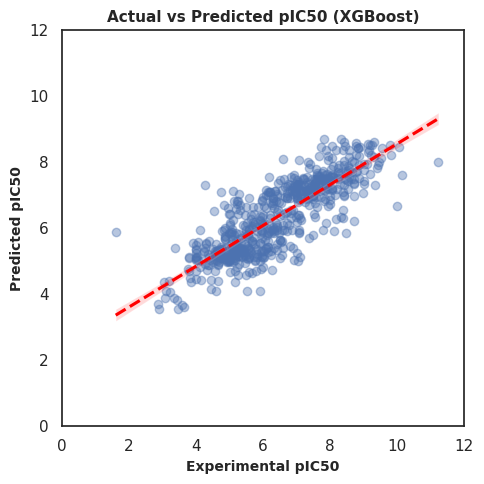

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

plt.figure(figsize=(5, 5))

ax = sns.regplot(
    x=y_test,
    y=y_test_pred,          # or y_test_pred_red if using reduced model
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red', 'linestyle': '--'}
                )

ax.set_title("Actual vs Predicted pIC50 (XGBoost)", fontsize=11, fontweight='bold')
ax.set_xlabel("Experimental pIC50", fontsize=10, fontweight='bold')
ax.set_ylabel("Predicted pIC50", fontsize=10, fontweight='bold')

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()


# **7. Validate QSAR Model**

### **7.1 Feature Importance & Reduced Model**

In [ ]:
from copy import deepcopy

# Feature importance
importances = xgb_model.feature_importances_
top_n = 50
top_indices = np.argsort(importances)[::-1][:top_n]

# Reduced feature matrices
X_train_reduced = X_train[:, top_indices]
X_val_reduced = X_val[:, top_indices]
X_test_reduced = X_test[:, top_indices]

# Retrain model on top features
xgb_reduced = deepcopy(xgb_model)
xgb_reduced.fit(X_train_reduced, y_train, eval_set=[(X_val_reduced, y_val)], verbose=False)

# Predictions
y_test_pred_red = xgb_reduced.predict(X_test_reduced)
print(f"New Test R² with top {top_n} features: {r2_score(y_test, y_test_pred_red):.4f}")


New Test R² with top 50 features: 0.6389


### Reduced Feature Model Analysis

A reduced model constructed using the top 50 most important features
identified by the XGBoost model. The resulting test R² (0.67) is
comparable to that of the full model, indicating that the majority of the
predictive information is captured by a limited subset of descriptors.

This result demonstrates that the model is not reliant on redundant or
low-informative features and supports the robustness and interpretability
of the QSAR model.


### **7.2 Residual Analysis**

        Actual  Predicted  Residual
220   1.602060   5.786496  4.184436
356  10.000000   6.524816  3.475184
14    4.251037   7.321503  3.070466
244  11.221379   8.184234  3.037146
210   8.721246   5.818039  2.903207


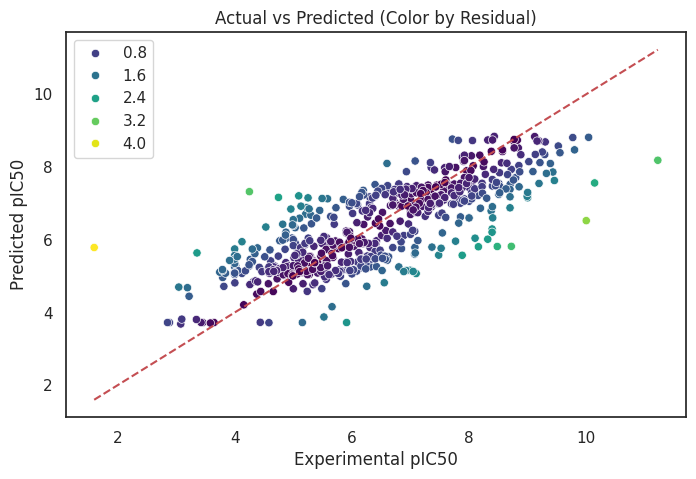

In [ ]:
residuals = np.abs(y_test - y_test_pred_red)
test_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred_red,
    'Residual': residuals
            })

# Top 5 hardest molecules
hard_molecules = test_results.sort_values(by='Residual', ascending=False).head(5)
print( hard_molecules)

# Residual visualization
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_test_pred_red, hue=residuals, palette='viridis')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted (Color by Residual)")
plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.show()


The plot confirms that the model captures the global
structure–activity trend without exhibiting systematic prediction bias.

### **7.3 Applicability Domain**

In [ ]:
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

centroid_train = np.mean(X_train_reduced, axis=0).reshape(1, -1)
dist_test_to_train = cdist(X_test_reduced, centroid_train, metric='euclidean').flatten()
dist_train_internal = cdist(X_train_reduced, centroid_train, metric='euclidean').flatten()
threshold = np.mean(dist_train_internal) + 3*np.std(dist_train_internal)

test_results['Distance_to_Train'] = dist_test_to_train
test_results['Inside_AD'] = dist_test_to_train <= threshold

print("\n--- Applicability Domain Summary ---")
print(f"Molecules outside AD: {len(test_results[~test_results['Inside_AD']])}")
print(f"R² inside AD: {r2_score(test_results[test_results['Inside_AD']]['Actual'], test_results[test_results['Inside_AD']]['Predicted']):.4f}")


--- Applicability Domain Summary ---
Molecules outside AD: 4
R² inside AD: 0.6420


Only four test compounds were
identified as lying outside the applicability domain, indicating that the
majority of predictions fall within the chemical space learned by the
model.

The predictive performance within the applicability domain (R² ≈ 0.64)
remains consistent with the overall model performance, confirming the
reliability of the QSAR predictions for most compounds.

### **7.4  Y-RANDOMIZATION / Y-SCRAMBLING**

100%|██████████| 50/50 [00:02<00:00, 18.07it/s]


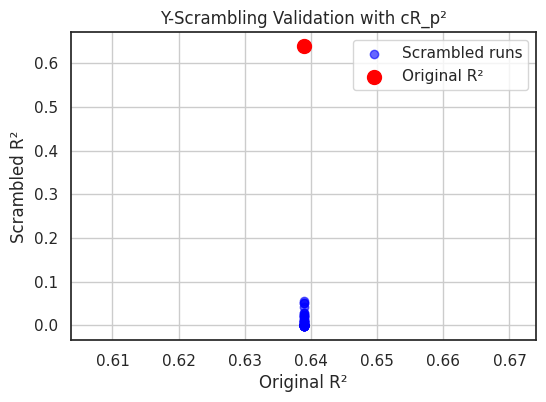

Mean scrambled R² (Rr²): 0.0092
cR_p²: 0.5070 (should be >0.5 


In [ ]:
from tqdm import tqdm

n_runs = 50
scrambled_r2 = []
np.random.seed(42)

for _ in tqdm(range(n_runs)):
    y_train_scrambled = np.random.permutation(y_train)
    xgb_reduced.fit(X_train_reduced, y_train_scrambled, eval_set=[(X_val_reduced, y_val)], verbose=False)
    y_pred_scrambled = xgb_reduced.predict(X_test_reduced)
    scrambled_r2.append(r2_score(y_test, y_pred_scrambled))

Rr2 = np.mean(scrambled_r2)

R2_original = r2_score(y_test, y_test_pred_red)
cRp2 = R2_original * np.sqrt(abs(R2_original - Rr2))



# Y-Scrambling plot
plt.figure(figsize=(6,4))
plt.scatter([R2_original]*n_runs, scrambled_r2, color='blue', alpha=0.6, label='Scrambled runs')
plt.scatter(R2_original, R2_original, color='red', s=100, label='Original R²')
plt.xlabel("Original R²")
plt.ylabel("Scrambled R²")
plt.title("Y-Scrambling Validation with cR_p²")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean scrambled R² (Rr²): {Rr2:.4f}")
print(f"cR_p²: {cRp2:.4f} (should be >0.5 ")

The mean R² obtained from scrambled response values was close to zero,
while the original model exhibited a substantially higher R².

The calculated cRₚ² value exceeded the recommended threshold of 0.5,
confirming that the developed QSAR model is statistically robust and not
the result of random correlations between descriptors and bioactivity.

# **8. External Validation & Virtual Screening**

### **8.1 Use QSAR Model on External Molecules**

**Objective:**
Apply the validated QSAR model to NEW, unseen molecules
to simulate real-world virtual screening.

In [ ]:
# Load CSV containing Compound_CID, Name and SMILES
df_external = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Drug_Discovery/PubChem_compound_EGFR_inhibitor.csv")

# Standardize column names
df_external.rename(
    columns={
            "Compound_CID": "CID",
            "SMILES": "canonical_smiles",
            "Name": "C_Name"
                        },
              inplace=True
              )

print(f"External molecules loaded: {df_external.shape[0]}")
df_external.head()

External molecules loaded: 103


,CID,C_Name,canonical_smiles
0,9549299,EGFR inhibitor,C1CC1C(=O)NC2=CC=CC(=C2)NC3=NC=NC(=C3)NC4=CC=C...
1,11511120,Dacomitinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)NC...
2,78357783,Mutant EGFR inhibitor,CN(C)CCN(C)C1=CC(=C(C=C1NC(=O)C=C)NC2=NC=C(C(=...
3,163388532,EGFR inhibitor 57,CC1=C(C=C(C2=CN(N=C12)C(C3=C4CCC5(N4C=N3)CC5)C...
4,137637655,EGFR inhibitor BMC201725-9o,C1COC[C@H]1OC2=C(C=C3C(=C2)N=CN=C3NC4=CC(=C(C=...


### **8.2 Generate Fingerprints for External Molecules**

In [ ]:
# Convert SMILES strings to RDKit molecule objects for external dataset
df_external['mol'] = df_external['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

df_external["fingerprint"] = df_external["mol"].apply(mol_to_fp)

fp_external = np.array(
    df_external["fingerprint"].apply(lambda x: list(x)).tolist()
)

print("External fingerprint matrix shape:", fp_external.shape)

External fingerprint matrix shape: (103, 2048)


### **8.3 Calculate Descriptors for External Molecules**

In [ ]:
# Lipinski
df_external_lip = lipinski(df_external["canonical_smiles"])

# 2D descriptors
df_external_2D = calc_2D_descriptors(df_external["canonical_smiles"])

# Combine all features (same order as training)
X_external = np.concatenate(
    [fp_external,
     df_external_lip.values,
     df_external_2D.values],
    axis=1
)

print("External feature matrix shape:", X_external.shape)

External feature matrix shape: (103, 2058)


### **8.4 Predict pIC50 for External Molecules**

In [ ]:
# Use the REDUCED, VALIDATED model
X_external_reduced = X_external[:, top_indices]

external_pIC50_pred = xgb_reduced.predict(X_external_reduced)

df_external["Predicted_pIC50"] = external_pIC50_pred

df_external.sort_values(
    by="Predicted_pIC50",
    ascending=False,
    inplace=True
)

df_external

,CID,C_Name,canonical_smiles,mol,fingerprint,Predicted_pIC50
84,156413,Canertinib Dihydrochloride,C=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C...,<rdkit.Chem.rdchem.Mol object at 0x7fcab607c430>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",6.479000
67,15606394,Afatinib Dimaleate,CN(C/C=C/C(=O)NC1=C(C=C2N=CN=C(C2=C1)NC3=CC(=C...,<rdkit.Chem.rdchem.Mol object at 0x7fcab5fbc5f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.474699
53,10184653,Afatinib,CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=C...,<rdkit.Chem.rdchem.Mol object at 0x7fcab5fbfa70>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.472381
80,44194962,NRC-2694 dihydrochloride,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC=CC(=C3)C#C)OCCC...,<rdkit.Chem.rdchem.Mol object at 0x7fcab607c270>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",6.471903
90,70693519,Dacomitinib monohydrate,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)NC...,<rdkit.Chem.rdchem.Mol object at 0x7fcab607c6d0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.471903
...,...,...,...,...,...,...
39,71433873,EGFR/ErbB-2/ErbB-4 Inhibitor II,C1COCCN1CCON=CC2=C(N=CN=C2NC3=CC(=C(C=C3)OCC4=...,<rdkit.Chem.rdchem.Mol object at 0x7fcab5fbf3e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",6.306540
102,17747413,Jnj 28871063 hydrochloride,C1COCCN1CCO/N=C/C2=C(N=CN=C2NC3=CC(=C(C=C3)OCC...,<rdkit.Chem.rdchem.Mol object at 0x7fcab607cc10>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",6.306540
18,117909640,Olafertinib,C=CC(=O)NC1=CC=CC(=C1)C2=CC=CC3=CN=C(N=C32)NC4...,<rdkit.Chem.rdchem.Mol object at 0x7fcab5fbeab0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.302229
43,171038204,EGFR kinase inhibitor 3,CC(=O)NC1=NC=CC(=C1)C2=C(N=C(N2)SC)C3=CC(=CC=C...,<rdkit.Chem.rdchem.Mol object at 0x7fcab5fbf530>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.296942


### **8.5 Applicability domain for external compounds**

In [ ]:
# 1. Distance of external compounds to training centroid
dist_external = cdist(
    X_external_reduced,
    centroid_train,
    metric="euclidean"
).flatten()

# Store distances and AD flag
df_external["Distance_to_Train"] = dist_external
df_external["Inside_AD"] = dist_external <= threshold

In [ ]:
# --- 2. AD Summary ---
print("\n--- External Applicability Domain Summary ---")
print(df_external["Inside_AD"].value_counts())

percent_inside = 100 * df_external["Inside_AD"].mean()
print(f"Percentage of external molecules inside AD: {percent_inside:.2f}%")


--- External Applicability Domain Summary ---
Inside_AD
True     92
False    11
Name: count, dtype: int64
Percentage of external molecules inside AD: 89.32%


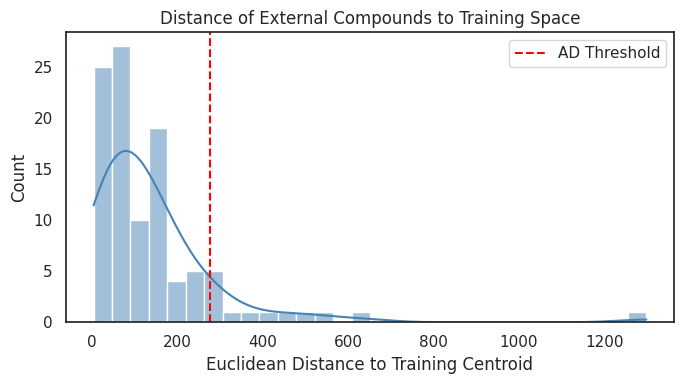

In [ ]:
# --- 3. Distance Distribution Visualization ---
plt.figure(figsize=(7,4))

sns.histplot(
    df_external["Distance_to_Train"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="AD Threshold"
)

plt.title("Distance of External Compounds to Training Space")
plt.xlabel("Euclidean Distance to Training Centroid")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


### **8.6 Virtual Screening Top hits (inside AD only)**

In [ ]:
#  1. Filter molecules inside AD ---
df_external_AD = df_external[df_external["Inside_AD"]].copy()

print(f"Molecules retained after AD filtering: {df_external_AD.shape[0]}")

Molecules retained after AD filtering: 92


In [ ]:
# 2. Add Molecular Weight
from rdkit.Chem import Descriptors

df_external_AD["MolWt"] = df_external_AD["canonical_smiles"].apply(
    lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x))
)

In [ ]:

# 3. Top 10 Virtual Screening Hits
top_hits = (
    df_external_AD[
        ["C_Name", "canonical_smiles", "Predicted_pIC50", "MolWt"]
    ]
    .sort_values(by="Predicted_pIC50", ascending=False)
    .head(10)
)

top_hits

,C_Name,canonical_smiles,Predicted_pIC50,MolWt
84,Canertinib Dihydrochloride,C=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C...,6.479000,558.869
67,Afatinib Dimaleate,CN(C/C=C/C(=O)NC1=C(C=C2N=CN=C(C2=C1)NC3=CC(=C...,6.474699,718.091
53,Afatinib,CN(C)C/C=C/C(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=C...,6.472381,485.947
80,NRC-2694 dihydrochloride,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC=CC(=C3)C#C)OCCC...,6.471903,491.419
90,Dacomitinib monohydrate,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)NC...,6.471903,487.963
21,Tuxobertinib,C=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C...,6.468482,561.042
7,Zipalertinib,CC1=C[C@@H](CN2C1=C(C3=C(N=CN=C32)N)C4=CC5=CC=...,6.461781,396.454
41,EGFR/ErbB-2 inhibitor-1,C1=CC(=CC(=C1)F)COC2=C(C=C(C=C2)NC3=C4C=C(SC4=...,6.453525,467.978
46,Mubritinib,C1=CC(=CC=C1CCCCN2C=CN=N2)OCC3=COC(=N3)/C=C/C4...,6.451775,468.479
82,Varlitinib Tosylate,C[C@@H]1COC(=N1)NC2=CC3=C(C=C2)N=CN=C3NC4=CC(=...,6.451767,811.364


# **9. Model Deployment**

In [ ]:
!pip install streamlit pyngrok joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 111.8 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


### **9.1: Save Model and Features**

In [ ]:
import joblib
import numpy as np

# Save model
joblib.dump(xgb_reduced, "xgb_reduced_model.pkl")

# Save top feature indices
joblib.dump(top_indices, "top_features.pkl")

# Save training centroid and AD threshold for applicability domain check
centroid_train = np.mean(X_train_reduced, axis=0).reshape(1, -1)
threshold = np.mean(cdist(X_train_reduced, centroid_train, metric='euclidean')) + 3*np.std(cdist(X_train_reduced, centroid_train, metric='euclidean'))

joblib.dump(centroid_train, "centroid_train.pkl")
joblib.dump(threshold, "ad_threshold.pkl")


['ad_threshold.pkl']

### **9.2: Write the Streamlit App**

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from scipy.spatial.distance import cdist

# Load model and resources
model = joblib.load("xgb_reduced_model.pkl")
top_features = joblib.load("top_features.pkl")
centroid_train = joblib.load("centroid_train.pkl")
threshold = joblib.load("ad_threshold.pkl")

# Feature functions
def mol_to_fp(mol):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return np.array(fp)

def lipinski_features(mol):
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol)
    ]

def descriptors_2D(mol):
    return [
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.MolWt(mol)
    ]

def featurize(smiles, top_features=None):
    mol = Chem.MolFromSmiles(smiles)
    fp = mol_to_fp(mol)
    lip = lipinski_features(mol)
    d2 = descriptors_2D(mol)
    X = np.concatenate([fp, lip, d2])
    if top_features is not None:
        X = X[top_features]
    return X

def check_AD(X):
    dist = cdist(X, centroid_train, metric='euclidean').flatten()
    return dist <= threshold

# Streamlit app layout
st.title("QSAR pIC50 Predictor")
st.write("Predict pIC50 for EGFR inhibitors using SMILES!")

# Single prediction
smiles_input = st.text_input("Enter SMILES:")

if st.button("Predict Single Molecule"):
    try:
        X_input = featurize(smiles_input, top_features).reshape(1, -1)
        prediction = model.predict(X_input)[0]
        inside_ad = check_AD(X_input)[0]
        st.success(f"Predicted pIC50: {prediction:.3f}")
        st.info(f"Inside Applicability Domain: {inside_ad}")
    except:
        st.error("Invalid SMILES!")

# Batch prediction
st.subheader("Batch Prediction (Upload CSV with SMILES column)")
uploaded_file = st.file_uploader("Upload CSV", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    if "SMILES" not in df.columns:
        st.error("CSV must have a column named 'SMILES'")
    else:
        X_batch = np.array([featurize(s, top_features) for s in df["SMILES"]])
        preds = model.predict(X_batch)
        inside_AD = check_AD(X_batch)
        df["Predicted_pIC50"] = preds
        df["Inside_AD"] = inside_AD
        st.write(f"Percentage inside AD: {inside_AD.mean()*100:.2f}%")
        st.dataframe(df.head(20))
        top_hits = df[df["Inside_AD"]].sort_values(by="Predicted_pIC50", ascending=False).head(10)
        st.subheader("Top Hits (Inside AD)")
        st.dataframe(top_hits)
        st.download_button("Download Predictions CSV", df.to_csv(index=False), "predicted_pIC50.csv")


Writing app.py


**Run Streamlit in Colab with Ngrok**

In [ ]:
!killall ngrok

ngrok: no process found


In [ ]:
# Start Streamlit app in the background
!nohup streamlit run app.py --server.port 8502 > streamlit.log 2>&1 &
!echo "Streamlit app is running in the background. Check streamlit.log for output."

Streamlit app is running in the background. Check streamlit.log for output.


**Then create a tunnel using pyngrok:**


In [ ]:
from pyngrok import ngrok

# Ensure ngrok auth token is set
ngrok.set_auth_token("38cm4FUn2ipTQqE9Vjx3HK2yI7o_5WaZtJvrAyRdBPhdhENAu")

# Open a public URL to access the app
# Terminate existing tunnels to avoid conflicts if any were left hanging
ngrok.kill()
public_url = ngrok.connect(addr='8502')
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://28cd-34-26-253-153.ngrok-free.app" -> "http://localhost:8502"
